In [15]:
# BLOCK 1: Load everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')  # ← This removes all warnings

# Load data (CHANGE THIS)
df = pd.read_csv("C:/Users/HP PROBOOK/Downloads/insurance.csv")

print("✅ Data loaded!")
print(f"Shape: {df.shape}")
print(df.head())

✅ Data loaded!
Shape: (1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


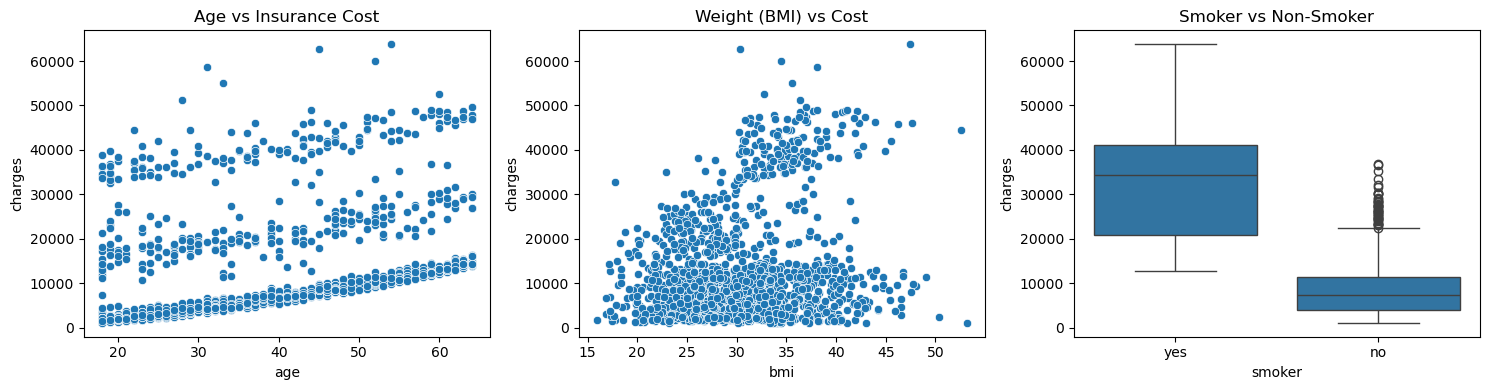

💡 Key insight: Smokers pay MUCH more for insurance!


In [16]:
# BLOCK 2: See what affects insurance cost
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Age effect
sns.scatterplot(data=df, x='age', y='charges', ax=axes[0])
axes[0].set_title('Age vs Insurance Cost')

# BMI effect
sns.scatterplot(data=df, x='bmi', y='charges', ax=axes[1])
axes[1].set_title('Weight (BMI) vs Cost')

# Smoker effect
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[2])
axes[2].set_title('Smoker vs Non-Smoker')

plt.tight_layout()
plt.show()

print("💡 Key insight: Smokers pay MUCH more for insurance!")

In [17]:
# BLOCK 3: Convert text to numbers
# Turn smoker into 1/0
df['is_smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# Turn gender into 1/0
df['is_male'] = df['sex'].map({'male': 1, 'female': 0})

# Pick features
X = df[['age', 'bmi', 'is_smoker', 'is_male']]
y = df['charges']

print("✅ Ready to predict insurance costs!")

✅ Ready to predict insurance costs!


In [18]:
# BLOCK 4: Train the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Calculate errors
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"\n📊 Model Performance:")
print(f"Average prediction error: ${mae:,.2f}")
print(f"Root mean square error: ${rmse:,.2f}")


📊 Model Performance:
Average prediction error: $4,260.99
Root mean square error: $5,874.99


In [19]:
# BLOCK 5: See how each factor affects cost
print("\n📈 How each factor affects insurance cost:")
print(f"Each year of age increases cost by: ${model.coef_[0]:.2f}")
print(f"Each BMI point increases cost by: ${model.coef_[1]:.2f}")
print(f"Being a smoker increases cost by: ${model.coef_[2]:.2f}")
print(f"Being male affects cost by: ${model.coef_[3]:.2f}")

# Test prediction
print("\n🔮 Example prediction:")
example = [[30, 25, 0, 1]]  # 30 year old, normal weight, non-smoker, male
pred = model.predict(example)
print(f"30-year old non-smoker male: ${pred[0]:,.2f}")

example_smoker = [[30, 25, 1, 1]]  # Same but smoker
pred_smoker = model.predict(example_smoker)
print(f"30-year old SMOKER male: ${pred_smoker[0]:,.2f}")
print(f"💰 Difference: ${pred_smoker[0] - pred[0]:,.2f} more for smokers!")


📈 How each factor affects insurance cost:
Each year of age increases cost by: $259.41
Each BMI point increases cost by: $326.44
Being a smoker increases cost by: $23674.55
Being male affects cost by: $9.37

🔮 Example prediction:
30-year old non-smoker male: $4,240.55
30-year old SMOKER male: $27,915.10
💰 Difference: $23,674.55 more for smokers!
